In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import joblib
import matplotlib.pyplot as plt
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Input 
from tensorflow.keras.models import Model
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Đặt seed để đảm bảo tính ngẫu nhiên của các cột mô phỏng là nhất quán
np.random.seed(42)

# =================================================================
# I. CHUẨN BỊ DỮ LIỆU MỞ RỘNG (2017-2021)
# =================================================================

# Đọc dữ liệu ban đầu
data_weather = pd.read_csv(r"D:\finalproject\KLTN\Backend\data\data\weather.csv")

# --- 1. Chuyển cột date về dạng datetime ---
data_weather['date'] = pd.to_datetime(data_weather['date'], errors='coerce')

# --- 2. Lọc dữ liệu chỉ lấy TỪ năm 2017 đến hết năm 2021 ---
data_weather = data_weather[data_weather['date'].dt.year >= 2017].reset_index(drop=True)

# Xác định độ dài dữ liệu cần thiết
history_start_date = data_weather['date'].min()
history_end_date = data_weather['date'].max()
history_length = (history_end_date - history_start_date).days + 1

# --- 3 & 4. Chuyển mốc thời gian để kết thúc vào 2025-11-04 ---
end_date_target = pd.Timestamp('2025-11-04')
start_date_target = end_date_target - pd.Timedelta(days=history_length - 1)

# Tạo dãy ngày mới khớp với độ dài lịch sử
valid_dates = pd.date_range(start=start_date_target, end=end_date_target)

# Giới hạn data_weather khớp với độ dài cần thiết
if len(data_weather) > len(valid_dates):
    data_weather = data_weather.tail(len(valid_dates)).reset_index(drop=True)
elif len(data_weather) < len(valid_dates):
    valid_dates = valid_dates[:len(data_weather)]

# Cập nhật lại cột date khớp với khoảng ngày mới
data_weather['date'] = valid_dates

# --- 5. Tạo DataFrame mới với LOGIC MÔ PHỎNG CHUỖI THỜI GIAN ---
df = pd.DataFrame()
N_DAYS = len(data_weather)
time_index = np.arange(N_DAYS)

# 5.1 Nhiệt độ trung bình (temperature)
trend_temp = np.linspace(-0.5, 1.5, N_DAYS)  # tăng nhẹ theo thời gian
daily_fluctuation = np.random.normal(0, 2, N_DAYS)  # dao động ngắn hạn
df['temperature'] = ((data_weather['max'] + data_weather['min']) / 2 + trend_temp + daily_fluctuation).round(1)

# 5.2 Độ ẩm (humidity)
noise_humidity = np.random.normal(0, 5, N_DAYS)
df['humidity'] = np.clip(data_weather['humidi'] + noise_humidity, 40, 100).round(1)

# 5.3 Độ ẩm đất (soil_moisture)
amplitude = 15
mean_value = 22.5
seasonal_moisture = mean_value + amplitude * np.sin(time_index * 2 * np.pi / 365.25)
noise_moisture = np.random.normal(0, 4, N_DAYS)  # nhiễu Gaussian
df['soil_moisture'] = np.clip(seasonal_moisture + noise_moisture, 0, 45).round(1)

# Thêm sự kiện bất thường: hạn hán hoặc mưa lớn
for i in range(0, N_DAYS, 180):
    if np.random.rand() > 0.5:  # 50% xảy ra hạn hán
        df.loc[i:i+5, 'soil_moisture'] -= np.random.uniform(5, 10)
    else:  # 50% xảy ra mưa lớn
        df.loc[i:i+3, 'soil_moisture'] += np.random.uniform(3, 8)
df['soil_moisture'] = np.clip(df['soil_moisture'], 0, 45)

# 5.4 Độ pH đất (soil_ph)
base_ph = 6.0
trend_ph = np.linspace(0, 1.0, N_DAYS)
noise_ph = np.random.normal(0, 0.3, N_DAYS)
df['soil_ph'] = np.clip(base_ph + trend_ph + noise_ph, 3, 9).round(1)

# 5.5 Cường độ ánh sáng (lux)
amplitude_lux = 20000
mean_lux = 25000
seasonal_lux = mean_lux + amplitude_lux * np.sin(time_index * 2 * np.pi / 365.25)
daily_lux_variation = np.random.normal(0, 7000, N_DAYS)
df['lux'] = np.clip(seasonal_lux + daily_lux_variation, 0, 50000).round(1)

# Thêm hiện tượng mưa kéo dài (ánh sáng giảm mạnh)
for i in range(0, N_DAYS, 120):
    if np.random.rand() > 0.6:
        df.loc[i:i+7, 'lux'] -= np.random.uniform(8000, 15000)
df['lux'] = np.clip(df['lux'], 0, 50000)

# 5.6 Gió hiện tại (wind)
df['wind'] = data_weather['wind']

# 5.7 Gió trung bình (wind_avg)
df['wind_avg'] = np.round(df['wind'] * np.random.uniform(0.7, 1.2, len(df)), 2)

# 5.8 Mực nước (water_level)
amplitude_water = 3
mean_water = 5
seasonal_water = mean_water + amplitude_water * np.sin(time_index * 2 * np.pi / 365.25)
noise_water = np.random.normal(0, 1, N_DAYS)
df['water_level'] = np.clip(seasonal_water + noise_water, 0, 10).round(1)

# Thêm mưa lũ bất thường
for i in range(0, N_DAYS, 200):
    if np.random.rand() > 0.7:
        df.loc[i:i+4, 'water_level'] += np.random.uniform(2, 4)
df['water_level'] = np.clip(df['water_level'], 0, 10)

# 5.9 Thời gian
df['timestamp'] = data_weather['date']

print("✅ Dữ liệu mô phỏng đã được làm NGẪU NHIÊN & THỰC TẾ hơn!")
print(f"Số dòng dữ liệu: {len(df)}")
print(f"Khoảng thời gian: {df['timestamp'].min()} → {df['timestamp'].max()}")

df.to_csv(r"D:\finalproject\KLTN\Backend\data\clean_data\weather_data\synthetic_weather.csv", index=False)
print("✅ Đã lưu dữ liệu mô phỏng thành synthetic_weather.csv")

✅ Dữ liệu mô phỏng đã được làm NGẪU NHIÊN & THỰC TẾ hơn!
Số dòng dữ liệu: 1630
Khoảng thời gian: 2021-05-20 00:00:00 → 2025-11-04 00:00:00
✅ Đã lưu dữ liệu mô phỏng thành synthetic_weather.csv


In [3]:
df.head()

,temperature,humidity,soil_moisture,soil_ph,lux,wind,wind_avg,water_level,timestamp
0,25.5,90.4,29.239283,6.1,21383.7,30,35.96,5.8,2021-05-20
1,27.2,58.8,30.639283,5.8,18181.3,24,22.72,5.1,2021-05-21
2,26.3,73.8,27.139283,5.8,27648.3,10,7.89,6.1,2021-05-22
3,30.0,79.1,35.739283,6.4,7309.7,25,23.91,5.0,2021-05-23
4,25.5,69.3,26.200000,6.3,14118.3,14,15.50,5.6,2021-05-24


In [4]:
# Ví dụ Python/Pandas
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

In [6]:
N_STEPS = 7    
N_FEATURES = 8

In [7]:
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        # Lấy chuỗi n_steps (ví dụ: 7 ngày) làm X
        end_ix = i + n_steps
        
        # Nếu end_ix vượt quá giới hạn, dừng lại
        if end_ix > len(data) - 1:
            break
            
        seq_x = data[i:end_ix]
        # Lấy ngày tiếp theo làm y (dự đoán 1 bước)
        seq_y = data[end_ix]
        
        X.append(seq_x)
        y.append(seq_y)
    
    return np.array(X), np.array(y)

In [8]:
X, y = create_sequences(scaled_data, N_STEPS)

print(f"Kích thước X (Input Sequences): {X.shape}") 
print(f"Kích thước y (Target): {y.shape}")

Kích thước X (Input Sequences): (1623, 7, 8)
Kích thước y (Target): (1623, 8)


In [9]:
# 2.1. Chia tập Train/Test theo thời gian
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("-" * 50)
print(f"Số lượng mẫu Train: {len(X_train)} ({train_size / len(X) * 100:.2f}%)")
print(f"Số lượng mẫu Test: {len(X_test)} ({(len(X) - train_size) / len(X) * 100:.2f}%)")
print("-" * 50)

--------------------------------------------------
Số lượng mẫu Train: 1298 (79.98%)
Số lượng mẫu Test: 325 (20.02%)
--------------------------------------------------


In [10]:
input_layer = Input(shape=(N_STEPS, N_FEATURES)) 
x = LSTM(units=32, activation='relu', return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, activation='relu')(x)
x = Dropout(0.2)(x)
output_layer = Dense(units=N_FEATURES)(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='mse')

In [11]:
# 3.2. Huấn luyện Mô hình
print("Bắt đầu huấn luyện mô hình...")
history = model.fit(
    X_train, y_train, 
    epochs=50, # Chọn số epochs phù hợp
    batch_size=32,
    validation_split=0.1, # Tách 10% từ tập Train để Validation
    verbose=1,
    shuffle=False # Quan trọng: Không xáo trộn dữ liệu chuỗi thời gian
)
print("✅ Huấn luyện hoàn tất!")

# 3.3. Xem biểu đồ Loss 
# Cần dùng matplotlib để vẽ biểu đồ loss (để tiết kiệm mã, ta bỏ qua phần này)

Bắt đầu huấn luyện mô hình...
Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2540 - val_loss: 0.1113
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1036 - val_loss: 0.0356
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0605 - val_loss: 0.0260
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0516 - val_loss: 0.0255
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0476 - val_loss: 0.0235
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0451 - val_loss: 0.0232
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0423 - val_loss: 0.0217
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0391 - val_loss: 0.0278
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0398 - val_loss: 0.0211
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0370 - val_loss: 0.0225
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0368 - val_loss: 0.0202
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4m

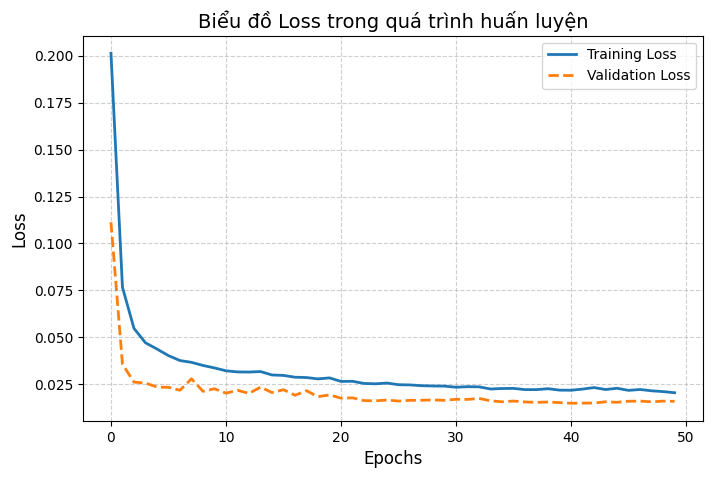

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--', linewidth=2)
plt.title('Biểu đồ Loss trong quá trình huấn luyện', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [13]:
# 4.1. Dự đoán trên tập Test
y_pred_scaled = model.predict(X_test)

# 4.2. Đảo ngược chuẩn hóa (Inverse Scaling)
# Chuyển đổi kết quả dự đoán (0-1) về giá trị thực
y_test_real = scaler.inverse_transform(y_test)
y_pred_real = scaler.inverse_transform(y_pred_scaled)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [14]:
# Tạo DataFrame để dễ dàng đánh giá từng cột
df_metrics = pd.DataFrame(index=df.columns)

for i, col in enumerate(df.columns):
    # Tính RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(y_test_real[:, i], y_pred_real[:, i]))
    # Tính MAE (Mean Absolute Error)
    mae = mean_absolute_error(y_test_real[:, i], y_pred_real[:, i])
    
    # Tính giá trị trung bình thực tế của cột đó trong tập test
    mean_value = y_test_real[:, i].mean()

    df_metrics.loc[col, 'RMSE'] = f"{rmse:.2f}"
    df_metrics.loc[col, 'MAE'] = f"{mae:.2f}"
    df_metrics.loc[col, 'Mean Value (Test)'] = f"{mean_value:.2f}"

print("\n\n📊 Bảng Đánh giá Hiệu suất Mô hình (RMSE & MAE trên tập Test):")
print("-" * 70)
print(df_metrics)
print("-" * 70)



📊 Bảng Đánh giá Hiệu suất Mô hình (RMSE & MAE trên tập Test):
----------------------------------------------------------------------
                  RMSE      MAE Mean Value (Test)
temperature       2.87     2.30             28.85
humidity          7.33     5.93             79.16
soil_moisture     4.86     3.84             22.51
soil_ph           0.40     0.33              6.89
lux            7496.68  6211.08          25135.50
wind              5.00     4.19             12.95
wind_avg          5.41     4.43             12.28
water_level       1.11     0.90              5.00
----------------------------------------------------------------------


In [15]:
# 5.1. Lấy N_STEPS (7 ngày) cuối cùng làm đầu vào cho dự báo
last_7_days_scaled = scaled_data[-N_STEPS:] 
forecast_input = last_7_days_scaled.reshape(1, N_STEPS, N_FEATURES) # Reshape (1, 7, 8)

N_FORECAST_DAYS = 3
forecast_results_scaled = []
current_input = forecast_input

print(f"\n\n🔮 Dự báo {N_FORECAST_DAYS} ngày sắp tới:")

for i in range(N_FORECAST_DAYS):
    # Dự đoán bước tiếp theo
    one_step_forecast_scaled = model.predict(current_input)
    forecast_results_scaled.append(one_step_forecast_scaled[0])
    
    # Cập nhật đầu vào cho lần dự đoán tiếp theo (Recursive Forecasting)
    # Loại bỏ ngày đầu tiên và thêm kết quả dự đoán vào cuối chuỗi
    current_input = np.roll(current_input, -N_FEATURES) # Dịch trái
    current_input[0, -1, :] = one_step_forecast_scaled[0]

# 5.2. Đảo ngược chuẩn hóa và hiển thị kết quả
forecast_results_scaled = np.array(forecast_results_scaled)
forecast_results_real = scaler.inverse_transform(forecast_results_scaled)

# 5.3. Tạo DataFrame kết quả
forecast_dates = pd.date_range(start=df.index.max() + pd.Timedelta(days=1), periods=N_FORECAST_DAYS)
df_forecast = pd.DataFrame(
    forecast_results_real, 
    index=forecast_dates, 
    columns=df.columns
).round(2)

print("-" * 70)
print(df_forecast)
print("-" * 70)



🔮 Dự báo 3 ngày sắp tới:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
----------------------------------------------------------------------
            temperature   humidity  soil_moisture  soil_ph           lux  \
2025-11-05    30.620001  79.970001      31.410000     6.71  35903.988281   
2025-11-06    30.610001  79.879997      31.190001     6.71  35563.890625   
2025-11-07    30.180000  81.519997      31.129999     6.74  35449.121094   

             wind  wind_avg  water_level  
2025-11-05  12.14     11.35         7.18  
2025-11-06  12.23     11.39         7.12  
2025-11-07  11.88     11.23         7.11  
----------------------------------------------------------------------


In [16]:
model.save("weather_prediction.h5")
joblib.dump(scaler, "scaler_weather.pkl")

['scaler_weather.pkl']

In [23]:
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = load_model(
    r"D:\finalproject\KLTN\Backend\Research\weather_prediction.h5",
    compile=False
)

In [13]:
import joblib

scaler = joblib.load("scaler_weather.pkl")

In [34]:
# =================================================================
# 6. PHÂN TÍCH CÁC TRƯỜNG HỢP NGOẠI LỆ (Stress Testing)
# =================================================================
np.random.seed(123)  # Để tái hiện kết quả

# Lấy lại dữ liệu đã scale và X_test, y_test như cũ
# (giả sử bạn đã chạy hết code phía trên)

# Tạo bản sao để không ảnh hưởng dữ liệu gốc
X_stress = X_test.copy()
y_stress = y_test.copy()

# Hàm chèn lỗi vào một đoạn dữ liệu
def inject_sensor_blocked(X, feature_idx, start_idx, duration=5, reduction_factor=0.75):
    end_idx = start_idx + duration
    X_copy = X.copy()
    X_copy[start_idx:end_idx, :, feature_idx] *= reduction_factor
    return X_copy

def inject_missing_data(X, start_idx, hours_missing=6):
    X_copy = X.copy()
    end_idx = start_idx + hours_missing
    if end_idx <= len(X_copy):
        X_copy[start_idx:end_idx, -hours_missing:, :] = 0
    return X_copy

def inject_spike(X, feature_idx, idx, spike_value=45.0, original_range=(20, 35)):
    X_copy = X.copy()
    scaled_spike = (spike_value - original_range[0]) / (original_range[1] - original_range[0])
    X_copy[idx, -1, feature_idx] = scaled_spike
    return X_copy

In [35]:
stress_scenarios = {
    "1. Mất kết nối ≥6 giờ": lambda X: inject_missing_data(X, start_idx=100, hours_missing=48),
    "2. Cảm biến ánh sáng bị che": lambda X: inject_sensor_blocked(X, feature_idx=4, start_idx=150, duration=10, reduction_factor=0.5),
    "3. Cảm biến độ ẩm đất bị bồi lấp": lambda X: inject_sensor_blocked(X, feature_idx=2, start_idx=80, duration=48, reduction_factor=0.7),
    "4. Spike nhiệt độ": lambda X: inject_spike(X, feature_idx=0, idx=200, spike_value=45.0),
    "5. Bảo trì đồng ruộng": lambda X: inject_sensor_blocked(X, feature_idx=2, start_idx=300, duration=24, reduction_factor=1.4),
}

results_stress = {}

results_stress = {}

for name, func in stress_scenarios.items():
    print(f"\nĐang mô phỏng: {name}")
    X_temp = X_test.copy()      
    
    X_temp = func(X_temp)        
    
    y_pred_stress_scaled = model.predict(X_temp)
    y_pred_stress_real = scaler.inverse_transform(y_pred_stress_scaled)
    y_test_real = scaler.inverse_transform(y_test)  
    
    rmse_list = []
    for i, col in enumerate(df.columns):
        rmse_real = np.sqrt(mean_squared_error(y_test_real[:, i], y_pred_stress_real[:, i]))
        rmse_list.append(rmse_real)
    
    results_stress[name] = rmse_list
    print(f"→ Hoàn thành: {name} | RMSE trung bình: {np.mean(rmse_list):.3f}")


Đang mô phỏng: 1. Mất kết nối ≥6 giờ
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
→ Hoàn thành: 1. Mất kết nối ≥6 giờ | RMSE trung bình: 977.177

Đang mô phỏng: 2. Cảm biến ánh sáng bị che
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
→ Hoàn thành: 2. Cảm biến ánh sáng bị che | RMSE trung bình: 986.211

Đang mô phỏng: 3. Cảm biến độ ẩm đất bị bồi lấp
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
→ Hoàn thành: 3. Cảm biến độ ẩm đất bị bồi lấp | RMSE trung bình: 973.086

Đang mô phỏng: 4. Spike nhiệt độ
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
→ Hoàn thành: 4. Spike nhiệt độ | RMSE trung bình: 978.699

Đang mô phỏng: 5. Bảo trì đồng ruộng
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
→ Hoàn thành: 5. Bảo trì đồng ruộng | RMSE trung bình: 994.628


In [36]:
# In bảng tổng hợp RMSE
print("\n" + "="*80)
print("KẾT QUẢ STRESS TESTING - RMSE TỪNG BIẾN")
print("="*80)
result_df = pd.DataFrame(results_stress, index=df.columns).T
result_df['RMSE_Trung_bình'] = result_df.mean(axis=1)
result_df


KẾT QUẢ STRESS TESTING - RMSE TỪNG BIẾN


,temperature,humidity,soil_moisture,soil_ph,lux,wind,wind_avg,water_level,RMSE_Trung_bình
1. Mất kết nối ≥6 giờ,2.879422,9.776885,4.631983,0.468411,7787.879312,5.226650,5.481855,1.075310,977.177478
2. Cảm biến ánh sáng bị che,2.833170,7.370311,4.701033,0.383220,7862.802882,5.159233,5.367935,1.067371,986.210644
3. Cảm biến độ ẩm đất bị bồi lấp,2.838821,7.388448,4.601422,0.382414,7757.862917,5.173108,5.371989,1.070592,973.086214
4. Spike nhiệt độ,2.838449,7.371247,4.640769,0.382691,7802.751192,5.160710,5.368946,1.077354,978.698920
5. Bảo trì đồng ruộng,2.839300,7.374316,4.820004,0.385998,7929.956681,5.157119,5.366874,1.124693,994.628123


In [37]:
# =========================
# Stress testing (mạnh hơn)
# =========================
import numpy as np
from sklearn.metrics import mean_squared_error
import pandas as pd

np.random.seed(123)

# --- Hàm tiện ích ---
def compute_rmse_range(y_true, y_pred, start, end):
    """Tính RMSE cho từng biến trong khoảng [start, end)"""
    rmse_list = []
    for i in range(y_true.shape[1]):
        rmse = np.sqrt(mean_squared_error(y_true[start:end, i], y_pred[start:end, i]))
        rmse_list.append(rmse)
    return rmse_list

def compute_rmse_all(y_true, y_pred):
    rmse_list = []
    for i in range(y_true.shape[1]):
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        rmse_list.append(rmse)
    return rmse_list

# --- Các hàm chèn lỗi mạnh hơn ---
def inject_missing_data_long(X, start_idx, hours_missing=48):
    X_copy = X.copy()
    end_idx = start_idx + hours_missing
    if end_idx > len(X_copy): 
        end_idx = len(X_copy)
        start_idx = max(0, end_idx - hours_missing)
    # đặt toàn bộ window về 0 cho tất cả timesteps (giả mất dữ liệu)
    X_copy[start_idx:end_idx, :, :] = 0
    return X_copy

def block_feature_zero(X, feature_idx, start_idx, duration=24):
    X_copy = X.copy()
    end = min(len(X_copy), start_idx + duration)
    X_copy[start_idx:end, :, feature_idx] = 0.0
    return X_copy

def inject_long_spike(X, feature_idx=0, start_idx=200, duration=20, spike_value=50.0, orig=(20,35)):
    X_copy = X.copy()
    scaled_spike = (spike_value - orig[0]) / (orig[1] - orig[0])
    end = min(len(X_copy), start_idx + duration)
    X_copy[start_idx:end, -1, feature_idx] = scaled_spike
    return X_copy

def invert_feature(X, feature_idx, start_idx=0, duration=None):
    X_copy = X.copy()
    end = len(X_copy) if duration is None else min(len(X_copy), start_idx + duration)
    # đảo giá trị normalized: x -> 1 - x
    X_copy[start_idx:end, :, feature_idx] = 1.0 - X_copy[start_idx:end, :, feature_idx]
    return X_copy

def shift_feature(X, feature_idx, shift_amount, start_idx=0, duration=None):
    X_copy = X.copy()
    end = len(X_copy) if duration is None else min(len(X_copy), start_idx + duration)
    X_copy[start_idx:end, :, feature_idx] += shift_amount
    # clamp to [0,1] nếu dữ liệu đã được scale
    X_copy[start_idx:end, :, feature_idx] = np.clip(X_copy[start_idx:end, :, feature_idx], 0, 1)
    return X_copy

def add_gaussian_noise(X, feature_idx, start_idx, duration, std=0.5):
    X_copy = X.copy()
    end = min(len(X_copy), start_idx + duration)
    noise = np.random.normal(loc=0.0, scale=std, size=X_copy[start_idx:end, :, feature_idx].shape)
    X_copy[start_idx:end, :, feature_idx] += noise
    X_copy[start_idx:end, :, feature_idx] = np.clip(X_copy[start_idx:end, :, feature_idx], 0, 1)
    return X_copy

# --- Định nghĩa các scenario mạnh hơn (vùng lỗi: start,end dùng khi tính RMSE vùng) ---
scenarios = {
    "Mất kết nối 48h (toàn cảm biến)": {
        "func": lambda X: inject_missing_data_long(X, start_idx=100, hours_missing=48),
        "window": (100, 148)
    },
    "Che cảm biến ánh sáng (về 0 trong 24h)": {
        "func": lambda X: block_feature_zero(X, feature_idx=4, start_idx=150, duration=24),
        "window": (150, 174)
    },
    "Bồi lấp độ ẩm - zero 48h": {
        "func": lambda X: block_feature_zero(X, feature_idx=2, start_idx=80, duration=48),
        "window": (80, 128)
    },
    "Spike nhiệt kéo dài 20h": {
        "func": lambda X: inject_long_spike(X, feature_idx=0, start_idx=200, duration=20, spike_value=50.0),
        "window": (200, 220)
    },
    "Đảo chiều soil_moisture 24h": {
        "func": lambda X: invert_feature(X, feature_idx=2, start_idx=300, duration=24),
        "window": (300, 324)
    },
    "Shift nhiệt +10C (toàn bộ test) (OOD)": {
        "func": lambda X: shift_feature(X, feature_idx=0, shift_amount=0.4, start_idx=0, duration=len(X)),
        "window": (0, len(X_test))
    },
    "Gaussian noise mạnh lên lux 48h": {
        "func": lambda X: add_gaussian_noise(X, feature_idx=4, start_idx=50, duration=48, std=0.8),
        "window": (50, 98)
    }
}

# --- Baseline (RMSE toàn bộ) để so sánh ---
y_pred_baseline = scaler.inverse_transform(model.predict(X_test))
baseline_all = compute_rmse_all(y_test_real := scaler.inverse_transform(y_test), y_pred_baseline)

# --- Chạy từng scenario ---
results = []
for name, info in scenarios.items():
    print(f"\n--- Chạy scenario: {name} ---")
    X_temp = X_test.copy()
    X_temp = info["func"](X_temp)
    
    # predict
    y_pred_scaled = model.predict(X_temp)
    y_pred_real = scaler.inverse_transform(y_pred_scaled)
    y_true_real = scaler.inverse_transform(y_test)
    
    # RMSE toàn bộ và RMSE vùng lỗi
    rmse_all = compute_rmse_all(y_true_real, y_pred_real)
    s,e = info["window"]
    s = max(0, s); e = min(len(y_true_real), e)
    rmse_window = compute_rmse_range(y_true_real, y_pred_real, s, e)
    
    # tỉ lệ thay đổi trung bình trên window so baseline window tương ứng (baseline window tính từ y_pred_baseline)
    baseline_window = compute_rmse_range(y_test_real, y_pred_baseline, s, e)
    pct_change_window = [ (rw - rb)/rb*100 if rb!=0 else np.nan for rw,rb in zip(rmse_window, baseline_window) ]
    
    # lưu kết quả (tổng hợp)
    results.append({
        "scenario": name,
        "window": (s,e),
        "rmse_all": rmse_all,
        "rmse_window": rmse_window,
        "baseline_window": baseline_window,
        "pct_change_window": pct_change_window,
        "mean_pct_change_window": np.nanmean(pct_change_window)
    })
    print(f"RMSE toàn bộ (mean): {np.mean(rmse_all):.3f} | RMSE vùng lỗi (mean): {np.mean(rmse_window):.3f} | Thay đổi trung bình vùng: {np.nanmean(pct_change_window):.1f}%")

# --- Chuyển kết quả thành DataFrame dễ đọc ---
rows = []
for r in results:
    row = {"scenario": r["scenario"], "window": f"{r['window'][0]}:{r['window'][1]}", 
           "RMSE_all_mean": np.mean(r["rmse_all"]), "RMSE_window_mean": np.mean(r["rmse_window"]),
           "Mean_pct_change_window": r["mean_pct_change_window"]}
    rows.append(row)

summary_df = pd.DataFrame(rows)
print("\n=== TÓM TẮT ===")
display(summary_df)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

--- Chạy scenario: Mất kết nối 48h (toàn cảm biến) ---
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
RMSE toàn bộ (mean): 977.177 | RMSE vùng lỗi (mean): 995.460 | Thay đổi trung bình vùng: 42.2%

--- Chạy scenario: Che cảm biến ánh sáng (về 0 trong 24h) ---
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
RMSE toàn bộ (mean): 1100.075 | RMSE vùng lỗi (mean): 2031.079 | Thay đổi trung bình vùng: 41.1%

--- Chạy scenario: Bồi lấp độ ẩm - zero 48h ---
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
RMSE toàn bộ (mean): 969.236 | RMSE vùng lỗi (mean): 931.977 | Thay đổi trung bình vùng: -0.9%

--- Chạy scenario: Spike nhiệt kéo dài 20h ---
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
RMSE toàn bộ (mean): 981.557 | RMSE vùng lỗi (mean): 748.983 | Thay đổi trung bình vùng: 3.9%

--- Chạy scenario: Đảo chiều soil_moisture 24h ---
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
RMSE toàn bộ (mean): 992.241 | RMSE vùng lỗi (mean): 1179.812 | Thay đổi trung bình vùng: 7.0%

--- Chạy scenar

,scenario,window,RMSE_all_mean,RMSE_window_mean,Mean_pct_change_window
0,Mất kết nối 48h (toàn cảm biến),100:148,977.177478,995.460186,42.179628
1,Che cảm biến ánh sáng (về 0 trong 24h),150:174,1100.074742,2031.079182,41.082820
2,Bồi lấp độ ẩm - zero 48h,80:128,969.236128,931.976636,-0.850403
3,Spike nhiệt kéo dài 20h,200:220,981.556640,748.983469,3.940533
4,Đảo chiều soil_moisture 24h,300:324,992.241453,1179.811764,7.039175
5,Shift nhiệt +10C (toàn bộ test) (OOD),0:325,950.181546,950.181546,6.025825
6,Gaussian noise mạnh lên lux 48h,50:98,1035.150293,1349.388650,12.755384


In [38]:
print(summary_df)

                                 scenario   window  RMSE_all_mean  \
0         Mất kết nối 48h (toàn cảm biến)  100:148     977.177478   
1  Che cảm biến ánh sáng (về 0 trong 24h)  150:174    1100.074742   
2                Bồi lấp độ ẩm - zero 48h   80:128     969.236128   
3                 Spike nhiệt kéo dài 20h  200:220     981.556640   
4             Đảo chiều soil_moisture 24h  300:324     992.241453   
5   Shift nhiệt +10C (toàn bộ test) (OOD)    0:325     950.181546   
6         Gaussian noise mạnh lên lux 48h    50:98    1035.150293   

   RMSE_window_mean  Mean_pct_change_window  
0        995.460186               42.179628  
1       2031.079182               41.082820  
2        931.976636               -0.850403  
3        748.983469                3.940533  
4       1179.811764                7.039175  
5        950.181546                6.025825  
6       1349.388650               12.755384  
